<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# Comparing Efficient Multi-Head Attention Implementations

This code notebook compares different ways to implement causal multi-head attention used in decoder-style LLMs like GPT, Llama, etc.

In [26]:
import torch  # 导入 PyTorch 主库，后面用它创建张量、选择设备并调用张量运算。

torch.manual_seed(123)  # 固定随机种子，让随机生成的 embedding 每次运行都一致，方便复现实验结果。
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 如果机器有 CUDA GPU 就用 GPU，否则退回 CPU。
print(f"PyTorch version: {torch.__version__}")  # 打印当前 PyTorch 版本，便于解释不同版本下可能出现的性能差异。
print(f"Running on {device}")  # 打印实际运行设备，确认后面的 benchmark 是在 CPU 还是 GPU 上执行。

batch_size = 8  # 一次送入模型的样本数量；这里模拟 8 条序列并行计算。
context_len = 1024  # 每条序列的 token 数量，也就是注意力能看到的上下文长度。
embed_dim = 768  # 每个 token 的向量维度；768 是 GPT-2 small 等模型常见的隐藏维度。
embeddings = torch.randn((batch_size, context_len, embed_dim), device=device)  # 随机生成输入 embedding，形状为 (批量大小, 序列长度, 嵌入维度)。

print(embeddings.shape)
print(embeddings)

PyTorch version: 2.12.0
Running on cpu
torch.Size([8, 1024, 768])
tensor([[[ 3.3737e-01, -1.7778e-01, -3.0353e-01,  ..., -3.1813e-01,
          -1.3936e+00,  5.2262e-01],
         [ 2.5787e-01,  3.4197e-01, -8.1678e-01,  ..., -4.0981e-01,
           4.9785e-01, -3.7207e-01],
         [ 7.9574e-01,  5.3501e-01,  9.4275e-01,  ..., -1.0749e+00,
           9.5492e-02, -1.4138e+00],
         ...,
         [-1.2094e+00,  6.3974e-01,  6.3416e-01,  ..., -4.5823e-01,
           1.4911e+00,  1.2406e+00],
         [-2.2531e-01, -1.0784e-01,  4.7894e-02,  ...,  2.5214e-01,
          -2.8927e-01, -5.6390e-01],
         [-5.3746e-01, -1.1562e+00,  2.2554e+00,  ...,  1.4322e+00,
           1.2488e+00,  1.8973e-01]],

        [[ 7.5794e-01, -6.9036e-01, -2.5187e-02,  ...,  1.1262e+00,
           9.5063e-01,  5.8597e-01],
         [ 6.3326e-01, -5.1637e-01,  2.1998e-01,  ..., -5.4707e-01,
          -7.6016e-01, -2.0981e+00],
         [ 1.4723e+00, -2.0736e+00,  7.9134e-01,  ..., -1.2537e+00,
          

<br>
&nbsp;

## 1) CausalAttention MHA wrapper class from chapter 3

In [27]:
from ch03 import MultiHeadAttentionWrapper as Ch03_MHA_Wrapper  # 从本目录的 ch03.py 导入第 3 章的“多头包装器”实现，并起一个更明确的别名。

mha_ch03_wrapper = Ch03_MHA_Wrapper(  # 创建第 1 种注意力模块：用多个独立 CausalAttention 头拼接而成。
    d_in=embed_dim,  # 输入维度等于 embedding 维度，即每个 token 有 768 个特征。
    d_out=embed_dim//12,  # 每个注意力头输出 64 维；12 个头拼接后回到 768 维。
    context_length=context_len,  # 设置最大上下文长度，用来创建因果 mask。
    dropout=0.0,  # 关闭 dropout，避免随机丢弃影响速度测试和输出复现。
    num_heads=12,  # 使用 12 个注意力头，这与 768 维隐藏层常见配置匹配。
    qkv_bias=False  # Q/K/V 线性投影不使用 bias，贴近许多 GPT 风格实现。
).to(device)  # 把模块参数和内部 buffer 移动到前面选择的 CPU 或 GPU 上。

out = mha_ch03_wrapper(embeddings)  # 将随机 embedding 输入包装版多头注意力，得到上下文向量。
print(out.shape)  # 打印输出形状，检查是否仍为 (8, 1024, 768)。
print(out)


torch.Size([8, 1024, 768])
tensor([[[-3.2218e-01, -5.8392e-01,  6.3387e-01,  ...,  1.9583e-01,
          -1.2520e-01,  9.2948e-02],
         [ 4.9431e-02, -3.7108e-01,  2.2676e-01,  ...,  2.2834e-01,
          -1.8087e-01,  2.2510e-01],
         [ 2.3612e-02, -2.2218e-01,  4.2796e-01,  ...,  1.1175e-01,
          -9.2387e-02, -3.1477e-02],
         ...,
         [ 3.2473e-02,  3.8170e-02,  1.9704e-02,  ..., -1.9235e-02,
          -1.7492e-02, -2.1902e-04],
         [ 2.6496e-02,  2.8208e-02,  1.4537e-02,  ..., -9.5416e-03,
          -2.4769e-03,  5.1361e-03],
         [ 3.3837e-02,  3.0047e-02,  1.8560e-02,  ..., -3.0104e-02,
          -1.4377e-02,  3.9969e-03]],

        [[-7.9835e-01, -1.7671e-01,  2.1255e-02,  ..., -8.3423e-02,
           4.9162e-01,  6.6328e-01],
         [-4.6230e-01, -2.2701e-01, -5.7163e-03,  ..., -8.3920e-02,
           3.4272e-01,  5.0159e-01],
         [-1.1449e-01,  1.8715e-01, -2.2245e-01,  ..., -6.0280e-02,
           1.2985e-01,  3.3984e-01],
         ...

<br>
&nbsp;

## 2) The multi-head attention class from chapter 3

In [28]:
from ch03 import MultiHeadAttention as Ch03_MHA  # 导入第 3 章更高效的多头注意力实现，它一次性处理所有 head。

mha_ch03 = Ch03_MHA(  # 创建第 2 种注意力模块：向量化的多头注意力类。
    d_in=embed_dim,  # 输入 token embedding 的维度是 768。
    d_out=embed_dim,  # 总输出维度仍设为 768，后续会平均分配给 12 个 head。
    context_length=context_len,  # 使用 1024 长度的因果 mask，保证每个 token 只能看见当前位置及之前的 token。
    dropout=0.0,  # 关闭 dropout，让性能比较聚焦在实现方式本身。
    num_heads=12,  # 把 768 维拆成 12 个 head，每个 head 处理 64 维。
    qkv_bias=False  # Q/K/V 线性层不加 bias，保持和其他实现的参数设置一致。
).to(device)  # 将模型移动到当前运行设备，避免输入和参数不在同一设备上。

out = mha_ch03(embeddings)  # 前向传播，计算第 3 章向量化 MHA 的输出。
print(out.shape)  # 打印输出形状，用于快速确认实现没有改变张量尺寸。
print(out)

torch.Size([8, 1024, 768])
tensor([[[-3.0444e-01, -2.2218e-01,  4.1740e-01,  ...,  2.9408e-01,
          -1.2849e-01,  1.3748e-01],
         [-6.1357e-02, -3.0025e-01,  2.3762e-01,  ..., -2.8785e-02,
          -1.1768e-01,  3.1449e-02],
         [ 1.0562e-01, -1.8908e-01,  1.1040e-02,  ..., -1.9277e-01,
          -1.7437e-01, -5.6488e-02],
         ...,
         [-6.1408e-03,  1.1379e-02, -5.0976e-03,  ...,  3.6709e-03,
          -2.9746e-02, -6.1438e-03],
         [ 1.4855e-02,  1.9130e-02, -1.4038e-02,  ...,  1.3104e-02,
          -3.0705e-02, -4.1437e-04],
         [ 6.4535e-03,  1.7320e-02, -1.8676e-02,  ...,  3.3902e-03,
          -2.1309e-02, -9.7254e-03]],

        [[-2.3375e-01, -2.8752e-01,  9.2432e-01,  ...,  1.9706e-01,
          -2.7502e-01,  3.1897e-02],
         [-1.7900e-01,  3.6432e-02,  5.4550e-01,  ...,  1.2195e-01,
          -1.1894e-02, -3.1787e-02],
         [-4.1447e-02, -2.8956e-02,  2.2226e-01,  ...,  2.0623e-01,
           2.2764e-01, -8.3939e-02],
         ...

<br>
&nbsp;

## 3) An alternative multi-head attention with combined weights

- The code for the `MultiHeadAttentionAlt` class below is based on code that was kindly shared by [Rayed Bin Wahed](https://github.com/rasbt/LLMs-from-scratch/discussions/51)
- The main difference between the `MultiHeadAttentionAlt` class and the `MultiHeadAttention` class used in chapter 3 is that `MultiHeadAttentionAlt` uses a single weight matrix, `self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)` instead of separate weight matrices:

  - `self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)`
  - `self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)`
  - `self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)`

- Here, `self.qkv` combines all three weight matrices `self.W_query`, `self.W_key`, and `self.W_value` to carry out the query, key, and value computation in a single step
- Using `q, k, v = qkv.unbind(0)`, we obtain the individual query, key, and value tensors, which are then used similarly to the query, key, and value tensors in the `MultiHeadAttention` class in chapter 3

In [29]:
import torch.nn as nn  # 导入 PyTorch 神经网络模块，后面要继承 nn.Module 并使用 Linear、Dropout 等层。


class MultiHeadAttentionCombinedQKV(nn.Module):  # 定义第 3 种实现：把 Query、Key、Value 三个投影合并到一个线性层里。
    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):  # 初始化模块，传入维度、头数、上下文长度和正则化配置。
        super().__init__()  # 调用父类初始化逻辑，让 PyTorch 正确注册参数和子模块。

        assert d_out % num_heads == 0, "embed_dim is indivisible by num_heads"  # 确保输出维度能被 head 数整除，否则无法平均拆成多个 head。

        self.num_heads = num_heads  # 保存注意力头数量，forward 中 reshape 时会用到。
        self.context_length = context_length  # 保存最大上下文长度，便于理解 mask 的设计范围。
        self.head_dim = d_out // num_heads  # 计算每个 head 的特征维度，例如 768/12=64。

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)  # 一个线性层同时生成 Q、K、V，总输出维度是 3 倍 d_out。
        self.proj = nn.Linear(d_out, d_out)  # 多个 head 拼接后再过一个输出投影层，用来融合各个 head 的信息。
        self.dropout = nn.Dropout(dropout)  # 对注意力权重做 dropout；本 notebook 中 dropout=0，所以实际不丢弃。

        self.register_buffer(  # 注册因果 mask 为 buffer：它会跟随模型迁移设备，但不会作为可训练参数更新。
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)  # 创建上三角矩阵，主对角线以上的位置代表“未来 token”。
        )  # register_buffer 调用结束，mask 的形状是 (context_length, context_length)。

    def forward(self, x):  # 定义前向传播，输入 x 的形状应为 (batch_size, num_tokens, embed_dim)。
        batch_size, num_tokens, embed_dim = x.shape  # 拆出批量大小、当前序列长度和输入 embedding 维度。

        # (b, num_tokens, embed_dim) --> (b, num_tokens, 3 * embed_dim)  # 下面的 qkv 线性层会把每个 token 一次性映射出 Q/K/V。
        qkv = self.qkv(x)  # 计算合并后的 QKV 张量，最后一维包含 query、key、value 三份信息。

        # (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)  # 把最后一维拆成 QKV 类型、head 数和每个 head 的维度。
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)  # reshape 只改变张量视图，便于后面按 Q/K/V 和 head 访问。

        # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)  # 调整维度顺序，让 Q/K/V 成为最前面的维度。
        qkv = qkv.permute(2, 0, 3, 1, 4)  # permute 后可以很方便地一次取出 queries、keys、values。

        # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_head, num_tokens, head_dim)  # 把合并张量拆回三个独立张量。
        queries, keys, values = qkv.unbind(0)  # 沿第 0 维拆分，得到 query、key、value，三者形状相同。

        # (b, num_heads, num_tokens, head_dim) --> (b, num_heads, num_tokens, num_tokens)  # 每个 query 与所有 key 做点积，得到 token 两两相关性。
        attn_scores = queries @ keys.transpose(-2, -1)  # 计算注意力分数矩阵；最后两维表示“当前 token 对历史 token”的打分。
        attn_scores = attn_scores.masked_fill(  # 用因果 mask 把未来位置填成负无穷，softmax 后这些位置权重会变成 0。
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf  # 只取当前序列长度对应的 mask，避免用到多余的上下文位置。
        )  # masked_fill 返回新的注意力分数张量，不会让未来 token 泄漏信息。

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**-0.5, dim=-1)  # 将分数归一化为概率；注意这里保留原 notebook 写法，标准缩放通常是除以 sqrt(head_dim)。
        attn_weights = self.dropout(attn_weights)  # 对注意力权重应用 dropout；dropout=0 时这一步等价于不改变权重。

        # (b, num_heads, num_tokens, num_tokens) --> (b, num_heads, num_tokens, head_dim)  # 用注意力权重对 value 加权求和。
        context_vec = attn_weights @ values  # 得到每个 head 内每个 token 的上下文向量。

        # (b, num_heads, num_tokens, head_dim) --> (b, num_tokens, num_heads, head_dim)  # 把 head 维移到 token 维后面，方便拼接所有 head。
        context_vec = context_vec.transpose(1, 2)  # 交换 num_heads 和 num_tokens 两个维度，为恢复总 embedding 维度做准备。

        # (b, num_tokens, num_heads, head_dim) --> (b, num_tokens, embed_dim)  # 把所有 head 的结果在最后一维重新拼起来。
        context_vec = context_vec.contiguous().view(batch_size, num_tokens, embed_dim)  # contiguous 保证内存连续，view 再把多个 head 合成一个向量。

        context_vec = self.proj(context_vec)  # 通过输出投影层融合各个 head 的信息，得到最终上下文表示。

        return context_vec  # 返回形状为 (batch_size, num_tokens, embed_dim) 的注意力输出。


mha_combined_qkv = MultiHeadAttentionCombinedQKV(  # 实例化合并 QKV 权重的多头注意力模块。
    d_in=embed_dim,  # 输入维度为 768，与随机 embedding 的最后一维一致。
    d_out=embed_dim,  # 输出维度也为 768，便于和其他实现公平比较。
    context_length=context_len,  # 使用 1024 长度的因果 mask。
    dropout=0.0,  # 关闭 dropout，使 benchmark 更稳定。
    num_heads=12,  # 使用 12 个注意力头。
    qkv_bias=False  # 合并的 QKV 线性层不使用 bias。
).to(device)  # 将模块移动到 CPU 或 GPU，与输入张量所在设备保持一致。

out = mha_combined_qkv(embeddings)  # 执行一次前向传播，验证合并 QKV 实现可以正常运行。
print(out.shape)  # 输出形状应与前面实现一致，都是 (8, 1024, 768)。
print(out)

torch.Size([8, 1024, 768])
tensor([[[ 0.2212,  0.1000,  0.5871,  ...,  0.5134,  0.3622, -0.4073],
         [ 0.0487,  0.2044,  0.5061,  ...,  0.4503,  0.3490, -0.2251],
         [ 0.3324,  0.5206,  0.4979,  ...,  0.6459,  0.2920, -0.2552],
         ...,
         [ 0.0889,  0.2643,  0.2520,  ..., -0.1364, -0.1304,  0.1949],
         [-0.1170, -0.2997,  0.0950,  ...,  0.2922, -0.5192,  0.2190],
         [-0.2332,  0.1895, -0.1848,  ...,  0.4250, -0.0385,  0.4507]],

        [[ 0.4033, -0.3930,  0.2607,  ...,  0.7337,  0.4061, -0.6105],
         [ 0.0906, -0.2109,  0.0620,  ...,  0.4983, -0.0544, -0.8056],
         [-0.5226,  0.1806,  0.3283,  ...,  0.6816, -0.2847, -0.0583],
         ...,
         [-0.1996,  0.2218,  0.1770,  ...,  0.4286,  0.2094,  0.2267],
         [ 0.1186,  0.3904,  0.2110,  ..., -0.4614,  0.4186,  0.2791],
         [-0.1266, -0.2295, -0.2954,  ...,  0.2603,  0.4831, -0.3504]],

        [[-0.1449, -0.2411,  0.3499,  ...,  0.4160, -0.5632, -0.1495],
         [-0.1785,

<br>
&nbsp;

## 4) Multihead attention with PyTorch's scaled dot product attention

- The implementation below uses PyTorch's [`scaled_dot_product_attention`](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html) function, which implements a memory-optimized version of self-attention calld [flash attention](https://arxiv.org/abs/2205.14135)

In [5]:
class MHAPyTorchScaledDotProduct(nn.Module):  # 定义第 4 种实现：手写 QKV 投影，但把注意力核心交给 PyTorch 优化函数。
    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):  # 初始化模块的维度、头数、上下文长度和 dropout 配置。
        super().__init__()  # 初始化 nn.Module 基类，确保参数和子模块会被 PyTorch 跟踪。

        assert d_out % num_heads == 0, "embed_dim is indivisible by num_heads"  # 检查输出维度是否能平均分给所有注意力头。

        self.num_heads = num_heads  # 保存 head 数量，用于 reshape 合并的 QKV 张量。
        self.context_length = context_length  # 保存上下文长度；本实现使用 is_causal=True，所以不需要手动创建 mask。
        self.head_dim = d_out // num_heads  # 每个 head 的维度，例如 64。
        self.d_out = d_out  # 保存总输出维度，后面把多头结果拼接回来时会用到。

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)  # 一个线性层同时生成 query、key、value，减少单独调用三层的开销。
        self.proj = nn.Linear(d_out, d_out)  # 输出投影层，用来混合不同 head 的信息。
        self.dropout = dropout  # 保存 dropout 概率；scaled_dot_product_attention 需要数值而不是 Dropout 模块。

    def forward(self, x):  # 定义前向传播，输入形状为 (batch_size, num_tokens, embed_dim)。
        batch_size, num_tokens, embed_dim = x.shape  # 读取输入张量的三个维度，后面 reshape 时要用。

        # (b, num_tokens, embed_dim) --> (b, num_tokens, 3 * embed_dim)  # 合并线性层一次性产生 Q/K/V。
        qkv = self.qkv(x)  # 计算合并后的 QKV 表示。

        # (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)  # 拆分最后一维，显式表示 QKV 和 head。
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)  # 把合并输出重排为多头注意力需要的结构。

        # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)  # 把 QKV 类型放到最前面，便于拆分。
        qkv = qkv.permute(2, 0, 3, 1, 4)  # 调整维度顺序以匹配 scaled_dot_product_attention 期望的输入布局。

        # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_heads, num_tokens, head_dim)  # 从合并张量中取出 Q、K、V。
        queries, keys, values = qkv  # 解包后每个张量都包含所有 batch、所有 head 和所有 token。

        use_dropout = 0. if not self.training else self.dropout  # 推理模式下必须把 dropout 设为 0；训练模式下使用初始化时给定的概率。
        context_vec = nn.functional.scaled_dot_product_attention(  # 调用 PyTorch 内置的缩放点积注意力，可能使用更省内存、更快的 kernel。
            queries, keys, values, attn_mask=None, dropout_p=use_dropout, is_causal=True)  # is_causal=True 表示自动使用因果 mask，禁止关注未来 token。

        # Combine heads, where self.d_out = self.num_heads * self.head_dim  # 将多个 head 的输出重新拼接成完整 embedding 维度。
        context_vec = context_vec.transpose(1, 2).contiguous().view(batch_size, num_tokens, self.d_out)  # 先把 head 维移回 token 后面，再合并 head_dim。

        context_vec = self.proj(context_vec)  # 通过输出线性层融合各 head 的信息。

        return context_vec  # 返回最终上下文向量，形状为 (batch_size, num_tokens, d_out)。

In [30]:
mha_pytorch_scaled = MHAPyTorchScaledDotProduct(  # 实例化使用 PyTorch scaled_dot_product_attention 的自定义 MHA。
    d_in=embed_dim,  # 输入维度为 768。
    d_out=embed_dim,  # 输出维度保持 768，方便与其他实现对齐。
    context_length=context_len,  # 记录上下文长度；该实现实际依赖 is_causal=True 自动处理因果约束。
    dropout=0.0,  # 关闭 dropout，保证速度和输出更稳定。
    num_heads=12,  # 使用 12 个注意力头。
    qkv_bias=False  # QKV 投影不加 bias，保持配置一致。
).to(device)  # 把模型移动到当前设备。

out = mha_pytorch_scaled(embeddings)  # 前向运行一次，确认 PyTorch SDPA 实现可用。
print(out.shape)  # 打印输出形状，应该是 (8, 1024, 768)。
print(out)

torch.Size([8, 1024, 768])
tensor([[[-5.0087e-01, -3.2779e-01,  6.6246e-02,  ...,  1.6162e-01,
           7.0868e-01,  1.5583e-01],
         [-3.5867e-01, -1.8324e-01,  1.8791e-01,  ..., -1.0639e-01,
           2.1238e-01,  7.8301e-02],
         [-4.0903e-01, -2.1847e-01,  2.6257e-01,  ..., -1.6983e-01,
           1.1469e-01, -5.4559e-03],
         ...,
         [-5.6145e-03,  2.5227e-02,  4.9857e-02,  ..., -3.7046e-02,
          -4.2265e-03, -1.6636e-02],
         [-1.3296e-02,  1.8224e-02,  5.6709e-02,  ..., -3.5985e-02,
          -6.5445e-03, -7.2141e-03],
         [-1.6005e-02,  2.6646e-02,  5.7513e-02,  ..., -3.6055e-02,
          -1.5655e-02, -8.2110e-03]],

        [[-3.2068e-01, -4.2247e-01,  7.9972e-01,  ..., -4.9390e-01,
           2.0014e-01, -1.7836e-01],
         [-3.1761e-01, -3.1302e-01,  8.6811e-02,  ..., -4.8407e-01,
          -5.6365e-02,  3.4055e-01],
         [-2.9447e-01, -3.4370e-01,  4.5393e-01,  ..., -3.9461e-01,
          -1.4621e-01,  2.0794e-01],
         ...

<br>
&nbsp;

## 5) Using PyTorch's torch.nn.MultiheadAttention

- Below, we use PyTorch's [torch.nn.MultiheadAttention](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) implementation

In [31]:
import torch.nn as nn  # 再次导入 nn 模块，保证单独运行这个 cell 时也能找到 nn.Module 和 nn.MultiheadAttention。


class MHAPyTorchClass(nn.Module):  # 定义第 5/6 种实现：用 PyTorch 官方 nn.MultiheadAttention 包装一个因果 MHA。
    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False, need_weights=True):  # 初始化官方 MHA 的参数，并允许控制是否返回注意力权重。
        super().__init__()  # 初始化父类，保证子模块会被正确注册。

        self.context_length = context_length  # 保存最大上下文长度，后面切片因果 mask 时会用到。
        self.multihead_attn = nn.MultiheadAttention(  # 创建 PyTorch 官方多头注意力层。
            embed_dim=d_out,  # 官方 MHA 的输入/输出嵌入维度；这里设为 768。
            num_heads=num_heads,  # 注意力头数量；必须能整除 embed_dim。
            dropout=dropout,  # 注意力内部 dropout 概率；benchmark 中为 0。
            bias=qkv_bias,  # 控制输入投影和输出投影是否使用 bias。
            add_bias_kv=qkv_bias,  # 控制是否为 key/value 额外添加 bias 向量，这里跟 qkv_bias 保持一致。
            batch_first=True,  # 让输入形状使用 (batch, tokens, features)，与本 notebook 其他实现一致。
        )  # 官方 MultiheadAttention 初始化结束。

        self.need_weights = need_weights  # 保存是否需要返回注意力权重；False 时通常能走更快的优化路径。
        self.proj = nn.Linear(d_out, d_out)  # 额外输出投影层；注意官方 MHA 内部本身也有一个输出投影。
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())  # 创建布尔型上三角因果 mask，并注册为 buffer。

    def forward(self, x):  # 定义前向传播，输入 x 形状为 (batch_size, num_tokens, d_out)。
        batch_size, num_tokens, _ = x.shape  # 读取 batch 大小和当前序列长度；下划线表示最后一维这里不需要显式使用。

        # Ensure attn_mask is compatible with expected shape and `batch_first=True`  # 确保传给官方 MHA 的 mask 与当前序列长度匹配。
        # No need to manually adjust for num_heads; ensure it's right for the sequence  # 这里的二维 mask 会由 PyTorch 自动广播到 batch/head 维度。
        if self.context_length >= num_tokens:  # 如果预先创建的 mask 足够长，就按当前 token 数量裁剪。
            attn_mask = self.mask[:num_tokens, :num_tokens]  # 取出当前序列对应的方形因果 mask。
        else:  # 如果输入序列比 context_length 还长，就退而使用已有 mask 的最大范围。
            attn_mask = self.mask[:self.context_length, :self.context_length]  # 这种分支通常不该触发，因为上下文长度应覆盖输入长度。

        # attn_mask broadcasting will handle batch_size dimension implicitly  # 官方 MHA 会隐式处理 batch 维度，不需要手动扩展 mask。
        attn_output, _ = self.multihead_attn(  # 调用官方多头注意力；第二个返回值是注意力权重，这里用下划线忽略。
            x, x, x, attn_mask=attn_mask, need_weights=self.need_weights  # 自注意力中 query/key/value 都是同一个 x，并传入因果 mask。
        )  # 官方 MHA 前向计算结束，得到每个 token 的上下文表示。

        output = self.proj(attn_output)  # 再经过一个线性投影层，保持与其他自定义实现的输出处理形式相似。

        return output  # 返回最终输出，形状为 (batch_size, num_tokens, d_out)。


mha_pytorch_class_default = MHAPyTorchClass(  # 实例化官方 nn.MultiheadAttention 的默认版本。
    d_in=embed_dim,  # 输入维度参数保留在接口中，但官方 MHA 实际使用 d_out 作为 embed_dim。
    d_out=embed_dim,  # 官方 MHA 的 embed_dim 设为 768。
    context_length=context_len,  # 创建 1024x1024 的因果 mask。
    dropout=0.0,  # 关闭 dropout，使性能测试稳定。
    num_heads=12,  # 使用 12 个注意力头。
    qkv_bias=False  # 不使用 bias，保持与其他实现一致。
).to(device)  # 把官方 MHA 包装模块移动到当前设备。

out = mha_pytorch_class_default(embeddings)  # 执行一次前向传播，测试默认 need_weights=True 的官方 MHA。
print(out.shape)  # 打印输出形状，确认仍然是 (8, 1024, 768)。
print(out)

torch.Size([8, 1024, 768])
tensor([[[-2.1644e-01, -1.0066e-01,  3.1364e-01,  ...,  2.3804e-01,
           9.4763e-02, -5.0138e-02],
         [ 3.1894e-02, -8.5756e-02,  5.0334e-02,  ...,  6.2169e-01,
           1.3307e-01, -1.9395e-01],
         [-8.2218e-02, -8.8428e-02,  7.7754e-02,  ...,  3.9191e-01,
           1.4341e-01, -2.4016e-01],
         ...,
         [ 3.3172e-02, -1.2993e-02, -2.7609e-02,  ...,  1.8568e-03,
           1.7769e-03, -1.3146e-02],
         [ 2.5079e-02, -1.6163e-02, -3.3468e-02,  ...,  1.4084e-02,
           2.9416e-03, -2.3556e-02],
         [ 3.3123e-02, -1.1661e-02, -2.4740e-02,  ...,  4.3409e-03,
           5.7991e-03, -1.4341e-02]],

        [[ 1.1195e-01,  2.5346e-02, -2.3917e-01,  ...,  3.3439e-01,
          -2.5549e-01, -1.0624e-01],
         [ 3.0740e-02, -1.3901e-01, -2.0005e-01,  ...,  2.3167e-01,
          -9.7706e-02,  1.6880e-02],
         [ 9.1925e-02, -6.7380e-02, -2.2202e-01,  ...,  7.6188e-02,
          -1.7075e-01, -6.3879e-02],
         ...

<br>
&nbsp;

## 6) Using PyTorch's torch.nn.MultiheadAttention with `scaled_dot_product_attention`

- Set `need_weights` (default `True`) to need_weights=False so that MultiheadAttention uses `scaled_dot_product_attention` [according to the documentation](https://github.com/pytorch/pytorch/blob/71d020262793542974cf13b30f2a9099773f015c/torch/nn/modules/activation.py#L1096)

>  need_weights: If specified, returns ``attn_output_weights`` in addition to ``attn_outputs``.
            Set ``need_weights=False`` to use the optimized ``scaled_dot_product_attention``
            and achieve the best performance for MHA.
            Default: ``True``.

In [32]:
mha_pytorch_class_noweights = MHAPyTorchClass(  # 实例化官方 MHA 的优化用法：不返回注意力权重。
    d_in=embed_dim,  # 输入维度保持 768，和随机 embedding 一致。
    d_out=embed_dim,  # 输出/嵌入维度为 768。
    context_length=context_len,  # 使用 1024 长度的因果 mask。
    dropout=0.0,  # 关闭 dropout，避免随机性影响 benchmark。
    num_heads=12,  # 使用 12 个注意力头。
    qkv_bias=False,  # 不使用 Q/K/V bias。
    need_weights=False  # 关键开关：不返回注意力权重，PyTorch 文档建议这样能获得最佳 MHA 性能。
).to(device)  # 将模块移动到当前运行设备。

out = mha_pytorch_class_noweights(embeddings)  # 前向运行一次，测试 need_weights=False 的官方 MHA。
print(out.shape)  # 打印输出形状，确认接口行为和默认版本一致。
print(out)

torch.Size([8, 1024, 768])
tensor([[[-1.0155e-01, -1.1573e-01,  2.1966e-02,  ..., -2.5172e-01,
          -2.6114e-01, -4.8158e-02],
         [-4.6618e-02,  3.1934e-02,  1.4790e-01,  ..., -1.2727e-01,
          -5.9959e-02, -1.3151e-01],
         [-1.0085e-01, -1.8030e-02, -7.7356e-02,  ..., -8.7893e-02,
          -2.0536e-01, -2.0540e-01],
         ...,
         [ 2.0021e-02,  1.7385e-02, -4.0450e-02,  ...,  4.8363e-03,
          -2.5826e-03,  1.9405e-02],
         [ 2.8239e-02,  6.4170e-03, -3.4129e-02,  ...,  4.9979e-04,
           1.0627e-02,  1.4671e-02],
         [ 2.0315e-02,  1.7309e-02, -2.8312e-02,  ...,  3.5257e-03,
          -3.8691e-03,  1.7502e-02]],

        [[ 2.9535e-01, -5.1619e-02,  7.3796e-02,  ...,  1.5574e-03,
           2.1876e-01,  2.0248e-01],
         [ 2.6206e-01, -1.7272e-02, -8.0825e-02,  ..., -2.3427e-01,
           3.1983e-01,  1.1429e-01],
         [ 2.3395e-01, -1.8949e-02, -1.1988e-01,  ..., -1.8390e-01,
           2.1090e-01,  1.7505e-02],
         ...

<br>
&nbsp;

## Quick speed comparison (M4 pro Macbook pro CPU)

In [33]:
## 1) CausalAttention MHA wrapper class from chapter 3  # 速度测试 1：第 3 章最直观的包装器版本，每个 head 是独立模块。
%timeit mha_ch03_wrapper(embeddings)  # 用 IPython 的 timeit 多次运行该模块，统计平均前向耗时。

77.7 ms ± 1.64 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [34]:
## 2) The multi-head attention class from chapter 3  # 速度测试 2：第 3 章向量化 MHA，一次性处理所有 head。
%timeit mha_ch03(embeddings)  # 测量向量化手写 MHA 的前向传播时间。

74.4 ms ± 3.23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [35]:
## 3) An alternative multi-head attention with combined weights  # 速度测试 3：合并 Q/K/V 投影矩阵的实现。
%timeit mha_combined_qkv(embeddings)  # 测量合并 QKV 权重后是否带来速度提升。

80.4 ms ± 193 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [36]:
## 4) Multihead attention with PyTorch's scaled dot product attention  # 速度测试 4：使用 PyTorch 内置 SDPA 核心函数。
%timeit mha_pytorch_scaled(embeddings)  # 测量 scaled_dot_product_attention 优化路径的前向耗时。

28.2 ms ± 319 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [37]:
## 5) Using PyTorch's torch.nn.MultiheadAttention  # 速度测试 5：官方 nn.MultiheadAttention 默认设置。
%timeit mha_pytorch_class_default(embeddings)  # 测量默认 need_weights=True 时官方 MHA 的前向耗时。

97.6 ms ± 631 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [38]:
## 6) Using PyTorch's torch.nn.MultiheadAttention disabling `need_weights`  # 速度测试 6：官方 MHA 关闭注意力权重返回。
%timeit mha_pytorch_class_noweights(embeddings)  # 测量 need_weights=False 是否触发更快路径。

41.6 ms ± 668 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


<br>
&nbsp;

## Quick speed comparison (Nvidia A100 GPU)

In [9]:
## 1) CausalAttention MHA wrapper class from chapter 3  # GPU 速度测试 1：包装器版本，多模块调用开销通常更明显。
%timeit mha_ch03_wrapper(embeddings)  # 在当前 GPU 输入上反复运行，统计包装版 MHA 的耗时。

8 ms ± 1.42 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
## 2) The multi-head attention class from chapter 3  # GPU 速度测试 2：第 3 章向量化 MHA。
%timeit mha_ch03(embeddings)  # 测量手写向量化实现的 GPU 前向耗时。

6.22 ms ± 490 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [11]:
## 3) An alternative multi-head attention with combined weights  # GPU 速度测试 3：合并 QKV 权重的版本。
%timeit mha_combined_qkv(embeddings)  # 测量合并投影层在 GPU 上的效果。

6.85 ms ± 824 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
## 4) Multihead attention with PyTorch's scaled dot product attention  # GPU 速度测试 4：PyTorch SDPA，通常能利用更优化的 attention kernel。
%timeit mha_pytorch_scaled(embeddings)  # 测量 SDPA 版本在 GPU 上的前向耗时。

2.95 ms ± 336 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
## 5) Using PyTorch's torch.nn.MultiheadAttention  # GPU 速度测试 5：官方 MHA 默认模式。
%timeit mha_pytorch_class_default(embeddings)  # 测量默认返回 attention weights 时的官方 MHA 性能。

6.39 ms ± 672 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [14]:
## 6) Using PyTorch's torch.nn.MultiheadAttention disabling `need_weights`  # GPU 速度测试 6：官方 MHA 关闭权重返回。
%timeit mha_pytorch_class_noweights(embeddings)  # 测量 need_weights=False 在 GPU 上带来的优化效果。

4.49 ms ± 3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<br>
&nbsp;


## Speed comparison (Nvidia A100 GPU) with warmup

In [15]:
# CUDA benchmark code shared by Andrei Aksionov  # 说明：下面的 CUDA 计时代码由 Andrei Aksionov 分享。
# and based on code from  # 说明：这段计时逻辑参考了 CUDA Mode 课程中的 PyTorch benchmark 示例。
# https://github.com/cuda-mode/lectures/blob/main/lecture1/pytorch_square.py  # 参考来源链接，方便追溯原始 benchmark 思路。

def time_pytorch_function(func, *input, num_repeats = 1_000):  # 定义 GPU 计时函数，func 是待测函数，input 是输入张量，num_repeats 是重复次数。
    # CUDA IS ASYNC so can't use python time module  # CUDA 操作默认异步执行，所以不能只用 Python 的 time 模块粗略计时。
    start = torch.cuda.Event(enable_timing=True)  # 创建 CUDA 起始事件，用 GPU 自己的时钟记录开始时间。
    end = torch.cuda.Event(enable_timing=True)  # 创建 CUDA 结束事件，用于记录结束时间。

    # Warmup  # 预热阶段：先运行几次，让 CUDA kernel 编译、缓存和调度进入稳定状态。
    for _ in range(5):  # 预热运行 5 次，避免第一次调用的额外开销污染正式计时。
        func(*input)  # 执行待测函数，但这几次不计入最终耗时。
    torch.cuda.synchronize()  # 等待所有预热 CUDA 操作完成，保证正式计时从干净状态开始。

    start.record()  # 在 GPU 时间线上记录正式计时的起点。
    for _ in range(num_repeats):  # 重复运行待测函数多次，降低单次测量噪声。
        func(*input)  # 执行一次待测函数前向传播。
        torch.cuda.synchronize()  # 每次运行后同步，确保该次计算真正完成再进入下一次。
    end.record()  # 在 GPU 时间线上记录正式计时的终点。
    torch.cuda.synchronize()  # 等待结束事件完成，确保 elapsed_time 读到的是完整耗时。
    return start.elapsed_time(end) / num_repeats  # 返回平均每次调用的毫秒数。

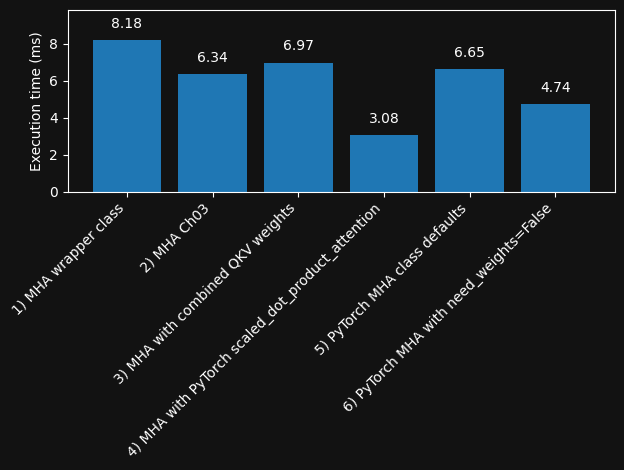

In [16]:
import matplotlib.pyplot as plt  # 导入 Matplotlib，用来把不同实现的 GPU 耗时画成柱状图。


embeddings_cuda = embeddings.to(torch.device("cuda"))  # 将输入 embedding 显式移动到 CUDA 设备，确保后面的 warmup benchmark 在 GPU 上运行。

functions = {  # 用字典保存“名称 -> 待测函数”，便于统一循环计时和画图。
    "1) MHA wrapper class": mha_ch03_wrapper,  # 第 1 个被测对象：第 3 章包装器版 MHA。
    "2) MHA Ch03": mha_ch03,  # 第 2 个被测对象：第 3 章向量化 MHA。
    "3) MHA with combined QKV weights": mha_combined_qkv,  # 第 3 个被测对象：合并 QKV 投影的自定义 MHA。
    "4) MHA with PyTorch scaled_dot_product_attention": mha_pytorch_scaled,  # 第 4 个被测对象：使用 PyTorch SDPA 的自定义 MHA。
    "5) PyTorch MHA class defaults": mha_pytorch_class_default,  # 第 5 个被测对象：官方 MultiheadAttention 默认设置。
    "6) PyTorch MHA with need_weights=False": mha_pytorch_class_noweights  # 第 6 个被测对象：官方 MultiheadAttention 关闭权重返回。
}  # 待测函数字典结束。
execution_times = [time_pytorch_function(fn, embeddings_cuda) for name,fn in functions.items()]  # 逐个函数运行 CUDA 计时，得到每种实现的平均耗时。


# Plotting  # 下面开始绘图，把 benchmark 结果可视化。

# Customize further for dark mode aesthetics  # 设置深色主题，让图在深色 notebook 或展示环境中更清楚。
plt.rcParams['figure.facecolor'] = '#121212'  # 设置整张图的背景色为深灰色。
plt.rcParams['axes.facecolor'] = '#121212'    # 设置坐标轴区域背景色为深灰色。
plt.rcParams['axes.edgecolor'] = 'white'      # 将坐标轴边框设置为白色，增强对比度。
plt.rcParams['axes.labelcolor'] = 'white'     # 将坐标轴标签文字设置为白色。
plt.rcParams['text.color'] = 'white'          # 将普通文本颜色设置为白色。
plt.rcParams['xtick.color'] = 'white'         # 将 x 轴刻度文字设置为白色。
plt.rcParams['ytick.color'] = 'white'         # 将 y 轴刻度文字设置为白色。
plt.rcParams['grid.color'] = '#444444'        # 设置网格线颜色为中灰，既可见又不刺眼。
plt.rcParams['lines.linewidth'] = 2           # 设置线条宽度；虽然柱状图不太依赖它，但保持全局风格一致。
plt.rcParams['lines.markersize'] = 8          # 设置标记点大小；同样是全局样式配置。

fig, ax = plt.subplots()  # 创建 Matplotlib 图对象和坐标轴对象。
bars = plt.bar(functions.keys(), execution_times)  # 画柱状图，横轴是实现名称，纵轴是平均执行时间。

plt.ylabel('Execution time (ms)')  # 设置 y 轴标题，单位是毫秒。
plt.xticks(rotation=45, ha="right")  # 将 x 轴标签旋转 45 度并右对齐，避免长名称互相重叠。

# Calculate new ylim with a margin  # 计算 y 轴上限，给柱子顶部的数字标签留出空间。
max_execution_time = max(execution_times)  # 找到所有实现中最慢的执行时间。
upper_ylim = max_execution_time + 0.2 * max_execution_time  # 在最大值基础上增加 20% 空白，避免标注贴到图边缘。

plt.ylim(0, upper_ylim)  # 设置 y 轴范围，从 0 到带余量的上限。

# Annotate bars with execution times  # 给每根柱子顶部添加具体耗时数字，读图时不用估算。
for bar in bars:  # 遍历柱状图中的每一根柱子。
    yval = bar.get_height()  # 读取当前柱子的高度，也就是对应实现的耗时。
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.05 * upper_ylim), round(yval, 2), ha='center', va='bottom')  # 在柱子上方居中写入保留两位小数的耗时。


plt.tight_layout()  # 自动调整布局，尽量避免标签、标题和图形元素重叠。
plt.savefig("1.pdf")  # 将图保存为 PDF 文件，方便在文档或论文中引用。
plt.show()  # 在 notebook 中显示柱状图。